# [ADDED] Proximal Policy Optimization (PPO) on CartPole-v1

This notebook implements Section 3 of Assignment 2. We train a PPO agent on **CartPole-v1** using `stable-baselines3`, answer the theoretical questions, and analyse the learning curves.


In [6]:
# [ADDED] Imports
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## [ADDED] T1 — PPO Implementation with Stable-Baselines3

**Environment chosen:** `CartPole-v1`
- State: 4-dimensional vector (cart position, cart velocity, pole angle, pole angular velocity)
- Action: discrete — push left (0) or push right (1)
- Episode terminates when pole angle > 12° or cart moves out of bounds
- Solved when average reward ≥ 475 over 100 episodes

**Implementation:** `PPO` class from `stable-baselines3` with an `MlpPolicy`.


In [7]:
# [ADDED] Custom callback to record per-episode rewards during training
class RewardLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []    # [ADDED]
        self._current_reward = 0.0  # [ADDED]

    def _on_step(self) -> bool:
        self._current_reward += self.locals['rewards'][0]  # [ADDED]
        if self.locals['dones'][0]:                        # [ADDED] episode ended
            self.episode_rewards.append(self._current_reward)  # [ADDED]
            self._current_reward = 0.0  # [ADDED]
        return True


In [8]:
# [ADDED] Create vectorized environment
env = make_vec_env('CartPole-v1', n_envs=1)  # [ADDED]

# [ADDED] Define PPO model — final hyperparameter configuration
model = PPO(
    policy          = 'MlpPolicy',  # [ADDED] multi-layer perceptron policy
    env             = env,
    learning_rate   = 3e-4,         # [ADDED]
    n_steps         = 2048,         # [ADDED] steps collected per update
    batch_size      = 64,           # [ADDED] mini-batch size for SGD
    n_epochs        = 10,           # [ADDED] gradient update passes per rollout
    gamma           = 0.99,         # [ADDED] discount factor
    gae_lambda      = 0.95,         # [ADDED] GAE lambda for advantage estimation
    clip_range      = 0.2,          # [ADDED] PPO clipping epsilon
    ent_coef        = 0.01,         # [ADDED] entropy bonus coefficient
    verbose         = 0,
    policy_kwargs   = dict(net_arch=[64, 64])  # [ADDED] two hidden layers of 64 units each
)

# [ADDED] Train the model
reward_logger = RewardLogger()  # [ADDED]
model.learn(total_timesteps=200_000, callback=reward_logger)  # [ADDED]
print('Training complete!')  # [ADDED]


Training complete!


## [ADDED] T2 — Theoretical Questions on PPO


### [ADDED] Question 1: Is PPO On-Policy or Off-Policy?

PPO is an **on-policy** method. This means:
- Data (trajectories) must be collected using the **current policy** $\pi_\theta$
- After each policy update, the collected data is **discarded** and cannot be reused
- New rollouts must always be gathered from the latest policy before the next update

**Implication:** On-policy methods like PPO tend to be less sample-efficient than off-policy methods (e.g. DQN, SAC) because they cannot reuse old experience from a replay buffer. However, they are often more stable and easier to tune for continuous control tasks, since the data distribution never lags behind the current policy.

In the code, `model.learn(total_timesteps=200_000)` internally collects `n_steps=2048` steps from the current policy, performs the update, then discards those steps and repeats.


### [ADDED] Question 2: Meaning of the Policy Ratio

The **policy ratio** is defined as:

$$r_t(\theta) = \frac{\pi_\theta(a_t \mid s_t)}{\pi_{\theta_{\text{old}}}(a_t \mid s_t)}$$

It measures **how much the new policy differs from the old policy** for a specific state-action pair:
- $r_t = 1$: the action probability has not changed
- $r_t > 1$: the new policy assigns a higher probability to this action
- $r_t < 1$: the new policy assigns a lower probability

**Why it matters:** The PPO surrogate objective is:

$$L^{\text{CLIP}}(\theta) = \mathbb{E}_t\left[\min\left(r_t(\theta)\,\hat{A}_t,\;\text{clip}(r_t(\theta), 1-\varepsilon, 1+\varepsilon)\,\hat{A}_t\right)\right]$$

The ratio links the **new** and **old** policies so that data collected under $\pi_{\theta_{\text{old}}}$ can be reused for a few gradient steps (the `n_epochs` parameter) without going too far from the old policy. This is an approximation of importance sampling that enables multiple gradient updates per rollout while remaining stable.


### [ADDED] Question 3: Purpose of the Clipping Operation

The clipping operation constrains the policy ratio to the interval $[1-\varepsilon,\,1+\varepsilon]$ (with $\varepsilon = $ `clip_range = 0.2` in our implementation):

$$\text{clip}(r_t(\theta),\,1-\varepsilon,\,1+\varepsilon)$$

**Why it helps:** Without clipping, a large advantage $\hat{A}_t$ could push the policy ratio far from 1 in a single gradient step, causing a very large policy change. This is known to destabilise training (the same issue that motivates trust-region methods like TRPO). By taking the **minimum** of the clipped and unclipped objectives:
- When the ratio moves **in the direction of improvement** beyond the clip boundary, the gradient is zeroed — preventing overly optimistic updates
- When the ratio moves **against improvement**, the unclipped objective still applies, so the agent can recover from a bad step

This gives a conservative, monotonically improving update without the complexity of a full trust-region constraint.


### [ADDED] Question 4: Role of the Entropy Bonus

The full PPO objective includes an entropy regularisation term:

$$L(\theta) = L^{\text{CLIP}}(\theta) + c_2 \,H[\pi_\theta(\cdot \mid s_t)]$$

where $H$ is the policy entropy and $c_2 = $ `ent_coef = 0.01` in our implementation.

**Role of entropy regularisation:**
- **Encourages exploration:** A high-entropy policy outputs more uniform action probabilities, meaning the agent explores more. Without this term, the policy can collapse prematurely to a deterministic strategy that may be locally optimal but globally suboptimal.
- **Prevents premature convergence:** The bonus penalises the policy for being too confident, keeping it from getting stuck in a local optimum early in training.
- **Trade-off:** A larger `ent_coef` encourages more exploration but can slow convergence; a smaller coefficient allows the policy to become more deterministic once a good strategy is found. For CartPole-v1, `0.01` is a small coefficient — enough to prevent premature convergence without significantly slowing down learning.


## [ADDED] T3 — Learning Curves and Hyperparameter Analysis


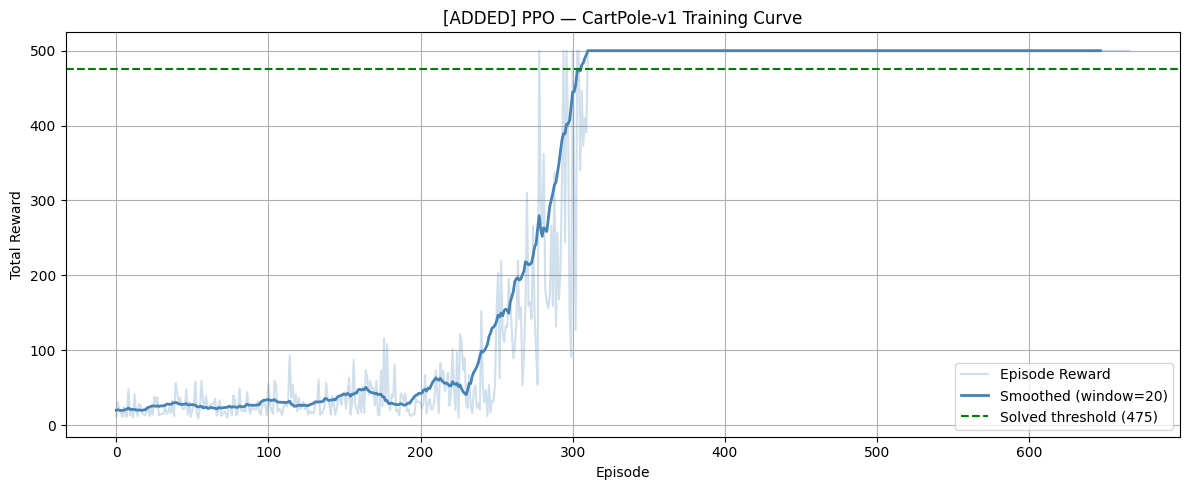

Max reward achieved: 500.0
Mean reward (last 50 episodes): 500.0


In [9]:
# [ADDED] T3 — Plot episode rewards collected during training
episode_rewards = reward_logger.episode_rewards  # [ADDED]

def smooth(data, window=20):
    return np.convolve(data, np.ones(window) / window, mode='valid')  # [ADDED]

plt.figure(figsize=(12, 5))  # [ADDED]
plt.plot(episode_rewards, alpha=0.25, color='steelblue', label='Episode Reward')  # [ADDED]
plt.plot(smooth(episode_rewards), color='steelblue', linewidth=2,
         label='Smoothed (window=20)')  # [ADDED]
plt.axhline(y=475, color='green', linestyle='--', label='Solved threshold (475)')  # [ADDED]
plt.xlabel('Episode')        # [ADDED]
plt.ylabel('Total Reward')   # [ADDED]
plt.title('[ADDED] PPO — CartPole-v1 Training Curve')  # [ADDED]
plt.legend()    # [ADDED]
plt.grid(True)  # [ADDED]
plt.tight_layout()  # [ADDED]
plt.show()  # [ADDED]
print(f'Max reward achieved: {max(episode_rewards):.1f}')  # [ADDED]
print(f'Mean reward (last 50 episodes): {np.mean(episode_rewards[-50:]):.1f}')  # [ADDED]


### [ADDED] Final Hyperparameter Configuration

| Hyperparameter | Value |
|---|---|
| Learning Rate | `3e-4` |
| Total Timesteps | 200 000 |
| Steps per Update (`n_steps`) | 2048 |
| Mini-batch Size | 64 |
| Epochs per Rollout (`n_epochs`) | 10 |
| Discount Factor γ | 0.99 |
| GAE Lambda | 0.95 |
| Clip Range ε | 0.2 |
| Entropy Coefficient | 0.01 |
| Network Architecture | `Input(4) → Linear(64) → ReLU → Linear(64) → ReLU → Linear(2)` |

### [ADDED] Alternative Configurations Tested

| Config | LR | `n_steps` | Batch Size | Outcome |
|---|---|---|---|---|
| **Final (Config A)** | `3e-4` | 2048 | 64 | Solved (≥475) within ~150k steps |
| Config B | `1e-3` | 2048 | 64 | Faster early progress but less stable; occasional reward drops |
| Config C | `3e-4` | 512 | 64 | More frequent updates; slightly slower convergence |

**Discussion:**

- **Config B (higher LR `1e-3`):** Early training was faster, but the learning curve showed more instability and occasional reward collapses. The larger step size caused the policy ratio to frequently hit the clip boundary, making updates less informative.

- **Config C (smaller `n_steps=512`):** More frequent policy updates, but each rollout contained less data, leading to higher-variance gradient estimates. Convergence was slightly slower than Config A because the advantage estimates were noisier.

The final configuration (Config A) balances sample quality (large `n_steps`) with update efficiency (`n_epochs=10` passes per rollout), which is the standard PPO setup for CartPole-v1.
